In [1]:
#run under deepchem environment
from rdkit import Chem
import matplotlib.pyplot as plt
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd

In [2]:
df_merged = pd.read_csv('covalent_noncovalent_MorganFP_bits_dataset.csv')
df_merged_base = df_merged[(df_merged['source'] == 'open_database') & (df_merged['cov_label'] == 0)]
df_merged_base = df_merged_base.iloc[:,:3]
df_merged_base['mol'] = df_merged_base['smiles'].apply(lambda x: Chem.MolFromSmiles(x))

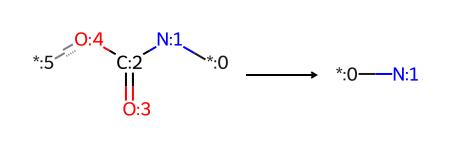

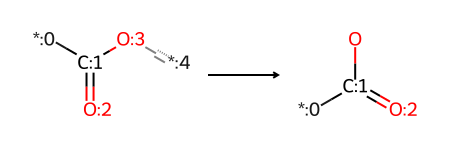

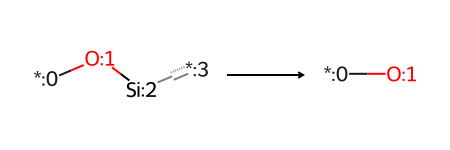

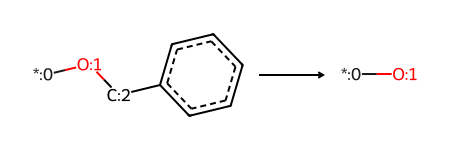

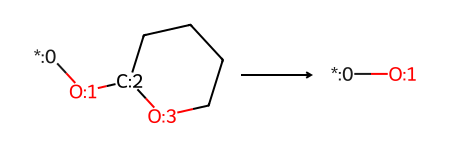

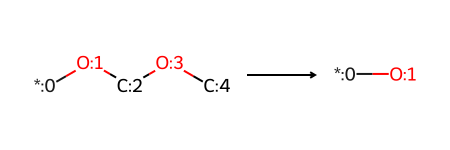

In [3]:
DEPROTECTION_RULES = {
    'Amine-from-carbamate': '[*:5][O:4]-[C:2](=[O:3])-[N:1]-[*:0]>>[N:1]-[*:0]',
    'Ester-hydrolysis': '[*:0]-[C:1](=[O:2])-[O:3][*:4]>>[*:0]-[C:1](=[O:2])-[O;H1]',
    'Hydroxyl-desilylation': '[*:0]-[O:1]-[Si:2][*:3]>>[*:0]-[O;H1:1]',
    'Hydroxyl-debenzylation': '[*:0]-[O:1]-[C;H2:2]-[c]:1:[c;H1]:[c;H1]:[c;H1]:[c;H1]:[c;H1]:1>>[*:0]-[O;H1:1]',
    'Hydroxyl-deprotection-from-THP': '[*:0]-[O:1]-[C;H1:2]-1-[C;H2]-[C;H2]-[C;H2]-[C;H2]-[O:3]-1>>[*:0]-[O;H1:1]',
    'Hydroxyl-deprotection-from-MOM': '[*:0]-[O:1]-[C;H2:2]-[O:3]-[C;H3:4]>>[*:0]-[O;H1:1]',
}
#
reactions = [AllChem.ReactionFromSmarts(s) for s in DEPROTECTION_RULES.values()]

for i in range(len(reactions)):
    display(reactions[i])

In [4]:
# remove all protecting groups from a molecule recursively until convergence

def remove_all_protecting_groups(mol, max_passes=10):
    """Remove all protecting groups from a molecule using predefined deprotection reactions."""
    # Work on a copy to avoid mutating caller's molecule
    current = Chem.Mol(mol)
    try:
        Chem.SanitizeMol(current)
    except Exception:
        pass
    last_smiles = Chem.MolToSmiles(current, isomericSmiles=True)

    for _ in range(max_passes):
        changed = False
        # Try each deprotection reaction; greedily accept first valid change
        for rxn in reactions:
            try:
                products_tuples = rxn.RunReactants((current,))
            except Exception:
                continue
            if not products_tuples:
                continue

            new_candidate = None
            for prod_tuple in products_tuples:
                for prod in prod_tuple:
                    try:
                        Chem.SanitizeMol(prod)
                        smi = Chem.MolToSmiles(prod, isomericSmiles=True)
                        if smi != last_smiles:
                            new_candidate = prod
                            break
                    except Exception:
                        continue
                if new_candidate:
                    break

            if new_candidate is not None:
                current = new_candidate
                last_smiles = Chem.MolToSmiles(current, isomericSmiles=True)
                changed = True
                # Continue looping; other reactions may still apply in this pass
        if not changed:
            break

    return current

In [5]:
df_merged_base['deprotected_mol'] = df_merged_base['mol'].apply(lambda x: remove_all_protecting_groups(x))
df_merged_base['scaffold'] = df_merged_base['deprotected_mol'].apply(lambda x: Chem.MolFromSmiles(MurckoScaffold.MurckoScaffoldSmiles(mol=x)))
mols = df_merged_base['scaffold'].tolist()

[12:13:24] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 5 4 2 3 
[12:13:24] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 4 
[12:13:24] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 3 
[12:13:24] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 
[12:13:24] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 3 
[12:13:24] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 3 4 
[12:13:25] non-ring atom 3 marked aromatic
[12:13:25] non-ring atom 20 marked aromatic
[12:13:25] non-ring atom 7 marked aromatic


Total number of unique scaffolds: 2394
Number of scaffolds successfully substituted: 2358
Number of scaffolds not substituted: 36
Total number of substituted scaffolds: 10583


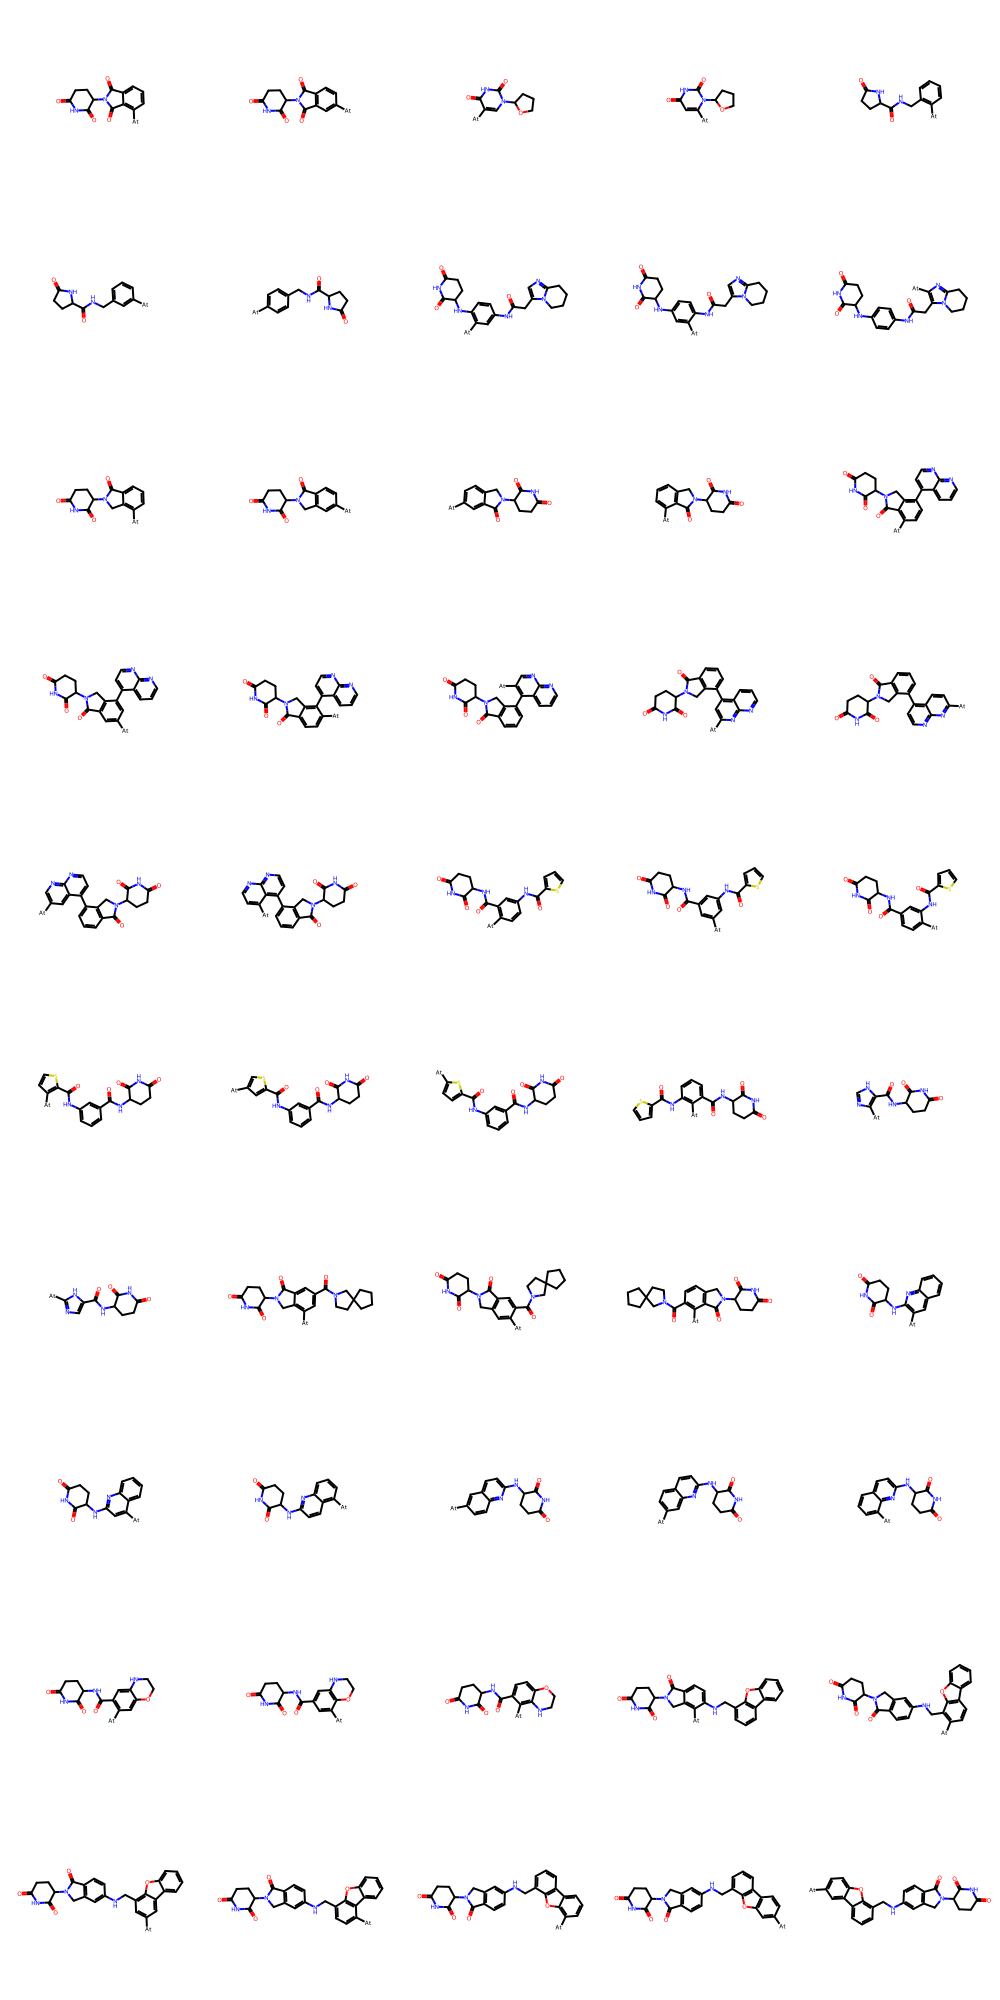

In [6]:
#remove duplicates
unique_smiles = set()
unique_mols = []
for m in mols:
    smi = Chem.MolToSmiles(m)
    if smi not in unique_smiles:
        unique_smiles.add(smi)
        unique_mols.append(m) 

print(f'Total number of unique scaffolds: {len(unique_mols)}')

# Define Reaction to replace Hydrogen on aromatic carbon with Astatine
# [c:1][H] matches aromatic carbon (1) attached to Hydrogen
# [c:1][At] keeps the carbon and attaches Astatine
replace_h_rxn = AllChem.ReactionFromSmarts('[c:1][H]>>[c:1][At]')

substrate = []
sub_count = 0
unsub_count = 0 
for mol in unique_mols:
    try:
        # Add explicit hydrogens to allow reaction with H
        mol_h = Chem.AddHs(mol)
        
        # Run the reaction
        # RunReactants returns a tuple of tuples of products
        # For each match of the reactants, one tuple of products is generated
        products_tuples = replace_h_rxn.RunReactants((mol_h,))
        
        valid_replaced = []
        for prod_tuple in products_tuples:
            for prod in prod_tuple:
                try:
                    # Remove Hs (this will remove the other Hs, but keep At)
                    # Note: At is not H, so it stays.
                    r = Chem.RemoveHs(prod)
                    Chem.SanitizeMol(r)
                    valid_replaced.append(r)
                except:
                    pass
        
        # Deduplicate if necessary (sometimes symmetry causes duplicates)
        # Using SMILES for deduplication
        unique_smiles = set()
        unique_mols = []
        for m in valid_replaced:
            smi = Chem.MolToSmiles(m)
            if smi not in unique_smiles:
                unique_smiles.add(smi)
                unique_mols.append(m)

        if unique_mols:
            substrate.extend(unique_mols)
            sub_count += 1
        else:
            unsub_count += 1
    except Exception as e:
        # print(e) # Optional debugging
        unsub_count += 1

print(f'Number of scaffolds successfully substituted: {sub_count}')
print(f'Number of scaffolds not substituted: {unsub_count}')
print(f'Total number of substituted scaffolds: {len(substrate)}')

if len(substrate) > 0:
    display(Draw.MolsToGridImage(substrate[:50], molsPerRow=5, subImgSize=(200,200)))
else:
    print("No substrates generated.")

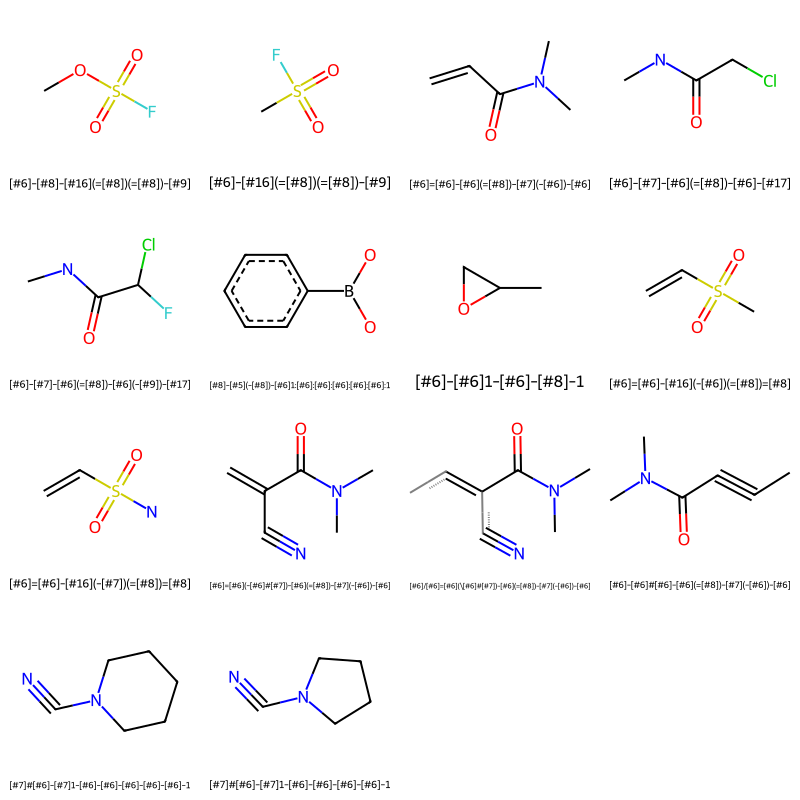

In [7]:
covalent_smiles_list = [
'COS(=O)(=O)F',
'CS(=O)(=O)F',
'C=CC(=O)N(C)C',
'CNC(=O)CCl',
'CNC(=O)C(F)Cl',
'OB(O)c1ccccc1',
'CC1CO1',
'C=CS(C)(=O)=O',
'C=CS(N)(=O)=O',
'C=C(C#N)C(=O)N(C)C',
'C/C=C(\C#N)C(=O)N(C)C',
'CC#CC(=O)N(C)C',
'N#CN1CCCCC1',
'N#CN1CCCC1'
]
smarts_mol_list = []
smarts_list = []
for i in covalent_smiles_list:
    mol = Chem.MolFromSmiles(i)
    Chem.SanitizeMol(mol)
    smarts = Chem.MolToSmarts(mol)
    smarts_list.append(smarts)
    smarts_mol = Chem.MolFromSmarts(smarts)
    smarts_mol_list.append(smarts_mol)
Draw.MolsToGridImage(smarts_mol_list, molsPerRow=4, legends=smarts_list, subImgSize=(200,200))

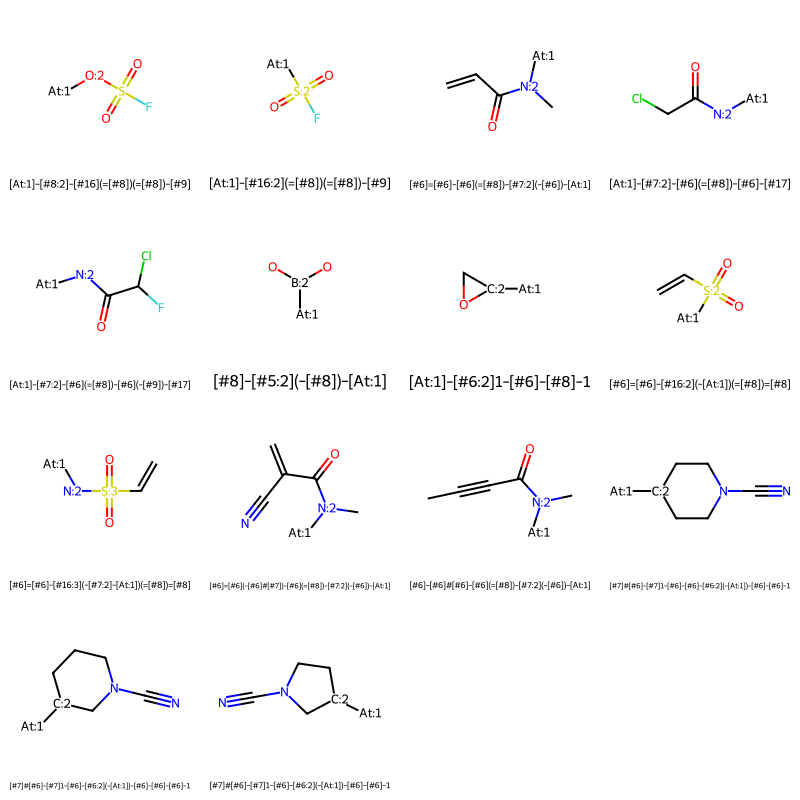

In [8]:
covalent_sub_list = [
'[At:1]-[#8:2]-[#16](=[#8])(=[#8])-[#9]',
'[At:1]-[#16:2](=[#8])(=[#8])-[#9]',
'[#6]=[#6]-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[At:1]-[#7:2]-[#6](=[#8])-[#6]-[#17]',
'[At:1]-[#7:2]-[#6](=[#8])-[#6](-[#9])-[#17]',
'[#8]-[#5:2](-[#8])-[At:1]',
'[At:1]-[#6:2]1-[#6]-[#8]-1',
'[#6]=[#6]-[#16:2](-[At:1])(=[#8])=[#8]',
'[#6]=[#6]-[#16:3](-[#7:2]-[At:1])(=[#8])=[#8]',
'[#6]=[#6](-[#6]#[#7])-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#6]-[#6]#[#6]-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#7]#[#6]-[#7]1-[#6]-[#6]-[#6:2](-[At:1])-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6:2](-[At:1])-[#6]-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6:2](-[At:1])-[#6]-[#6]-1'
]
warheads =[]
for i in covalent_sub_list:
    warhead = Chem.MolFromSmarts(i)
    Chem.SanitizeMol(warhead)
    warheads.append(warhead)
Draw.MolsToGridImage(warheads, molsPerRow=4, legends=covalent_sub_list, subImgSize=(200,200))

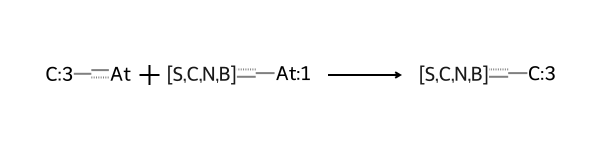

In [9]:
smarts_two_components_rxn = '[c:3][At].[At:1][S,C,N,B:2]>>[c:3][S,C,N,B:2]'
rxn = AllChem.ReactionFromSmarts(smarts_two_components_rxn)
rxn

Starting reaction with 10583 substrates and 14 warheads...


[12:13:54] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 1 


Total generated compounds: 137579


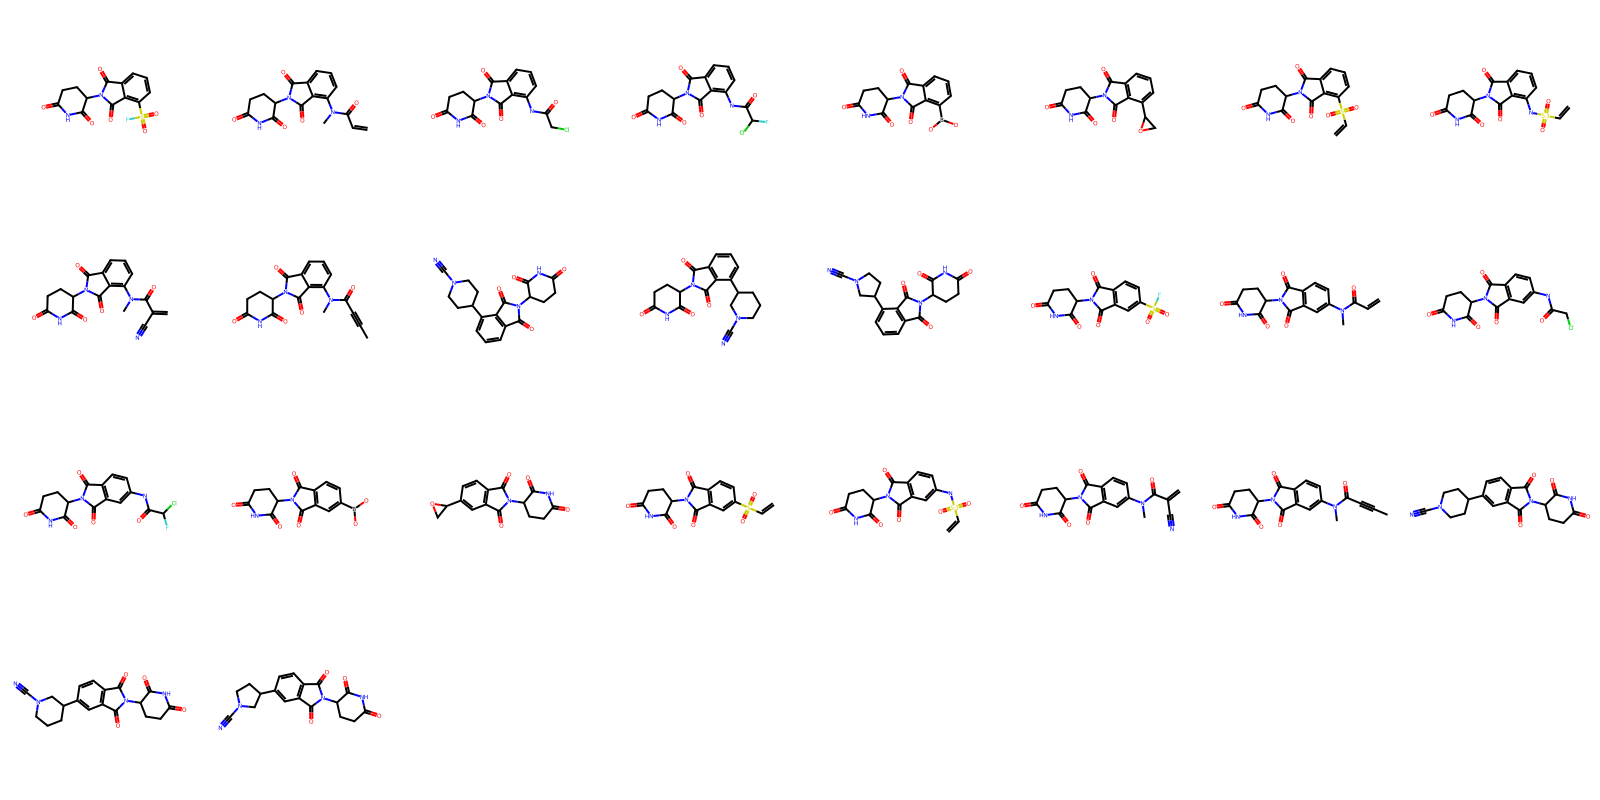

In [10]:
generated_compounds = []
print(f"Starting reaction with {len(substrate)} substrates and {len(warheads)} warheads...")

for sub_mol in substrate:
    for warhead_mol in warheads:
        try:
            products = rxn.RunReactants((sub_mol, warhead_mol))           
            for product_tuple in products:
                for prod in product_tuple:
                    try:
                        Chem.SanitizeMol(prod)
                        generated_compounds.append(prod)
                        #print('successfully generated compound')
                    except:
                        #print('failed to sanitize product')
                        continue
        except:
            #print('failed to react substrate and warhead')
            continue

print(f"Total generated compounds: {len(generated_compounds)}")
Draw.MolsToGridImage(generated_compounds[:26], molsPerRow=8, subImgSize=(200,200))

In [11]:
df_badsubstructures = pd.read_csv("unwanted_substructures.csv")
df_bad_excpet_cov = df_badsubstructures.loc[~df_badsubstructures['name'].isin(['alkyl-halide',
                                                                            'conjugated-nitrile-group',
                                                                            'cyanamide',
                                                                            'isolate-alkene',
                                                                            'Michael-acceptor',
                                                                            'phosphor-P-phthalimide',
                                                                            'triple-bond'])]

In [12]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'].isin(['heavy-metal', 'Three-membered-heterocycle', 'cyanate/aminonitrile/thiocyanate'])]

,name,smarts
27,cyanate/aminonitrile/thiocyanate,"[N,O,S]C#N"
44,heavy-metal,"[Hg,Fe,As,Sb,Zn,Se,se,Te,B,Si]"
100,Three-membered-heterocycle,"*1[O,S,N]*1"


In [13]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'Three-membered-heterocycle', 'smarts'] = '*1[S,N]*1'
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'heavy-metal', 'smarts'] = '[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]'
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'cyanate/aminonitrile/thiocyanate', 'smarts'] = '[O,S]C#N'

/tmp/ipykernel_243039/1541893138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'Three-membered-heterocycle', 'smarts'] = '*1[S,N]*1'
/tmp/ipykernel_243039/1541893138.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'heavy-metal', 'smarts'] = '[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]'
/tmp/ipykernel_243039/1541893138.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

In [14]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'].isin(['heavy-metal', 'Three-membered-heterocycle', 'cyanate/aminonitrile/thiocyanate'])]

,name,smarts
27,cyanate/aminonitrile/thiocyanate,"[O,S]C#N"
44,heavy-metal,"[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]"
100,Three-membered-heterocycle,"*1[S,N]*1"


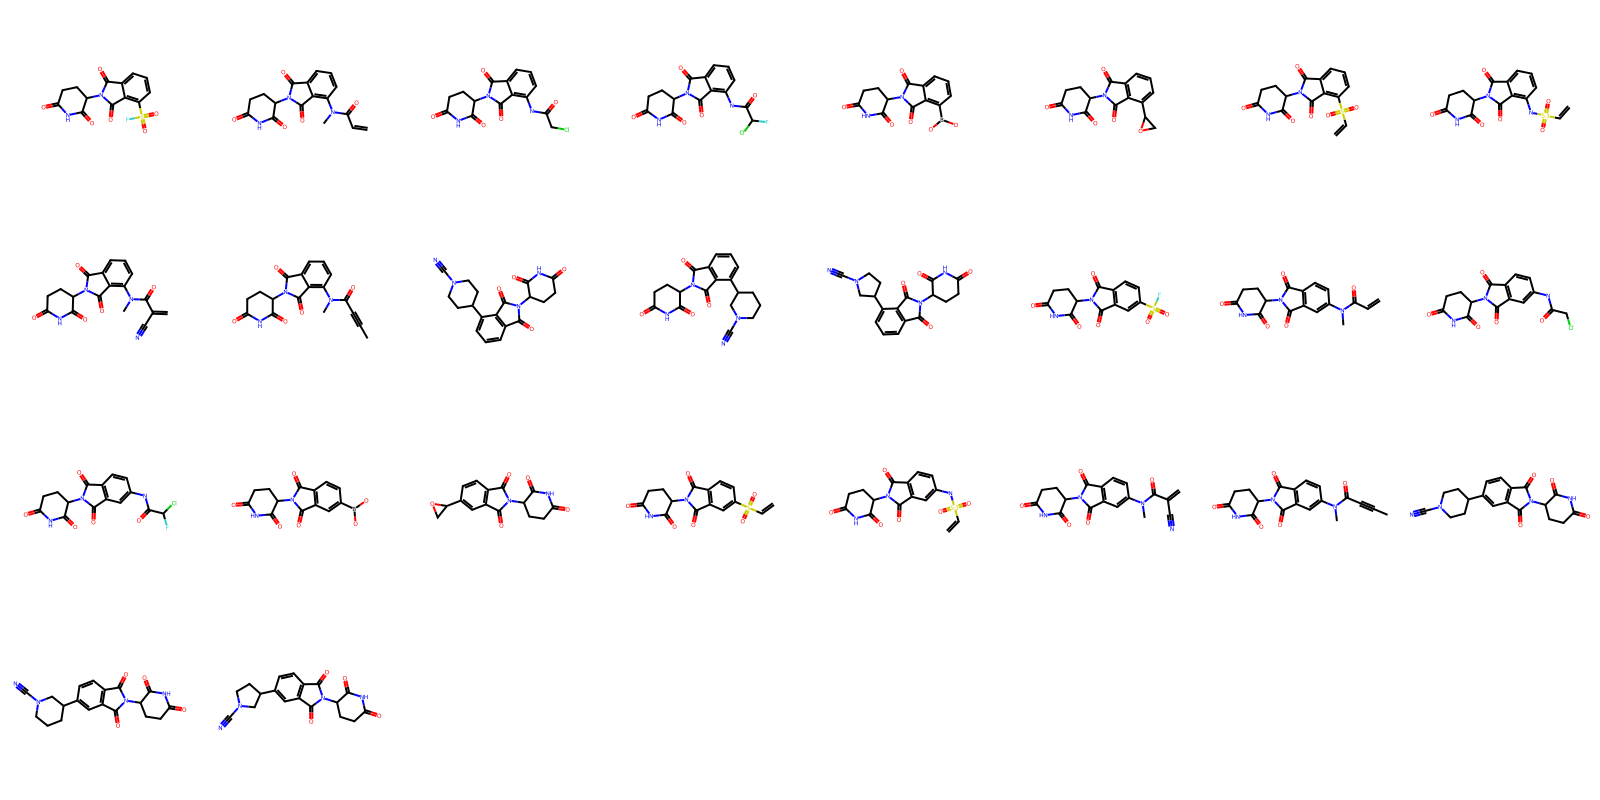

In [15]:
generated_compounds_testlist = generated_compounds[:26]
bad_dict = {}
for n, s in df_bad_excpet_cov[['name', 'smarts']].itertuples(index=False):
    bad_dict[n] = Chem.MolFromSmarts(s)

undesired = []
clean = []

for m in generated_compounds_testlist:
    match = False
    for substrate_name, substructure in bad_dict.items():
        if m.HasSubstructMatch(substructure):
            display(Draw.MolToImage(m, size=(300,300), legend=f'Matched undesired substructure: {substrate_name}'))
            undesired.append(m)
            match = True
            break
    if not match:
        clean.append(m)

Draw.MolsToGridImage(clean, molsPerRow=8, subImgSize=(200,200))

In [16]:
undesired = []
clean = []

for m in generated_compounds:
    match = False
    for substrate_name, substructure in bad_dict.items():
        if m.HasSubstructMatch(substructure):
            #display(Draw.MolToImage(m, size=(300,300), legend=f'Matched undesired substructure: {substrate_name}'))
            undesired.append(m)
            match = True
            break
    if not match:
        clean.append(m)

print(len(undesired), len(clean))

2938 134641


Number of clean compounds between 200 and 500 Da: 121639


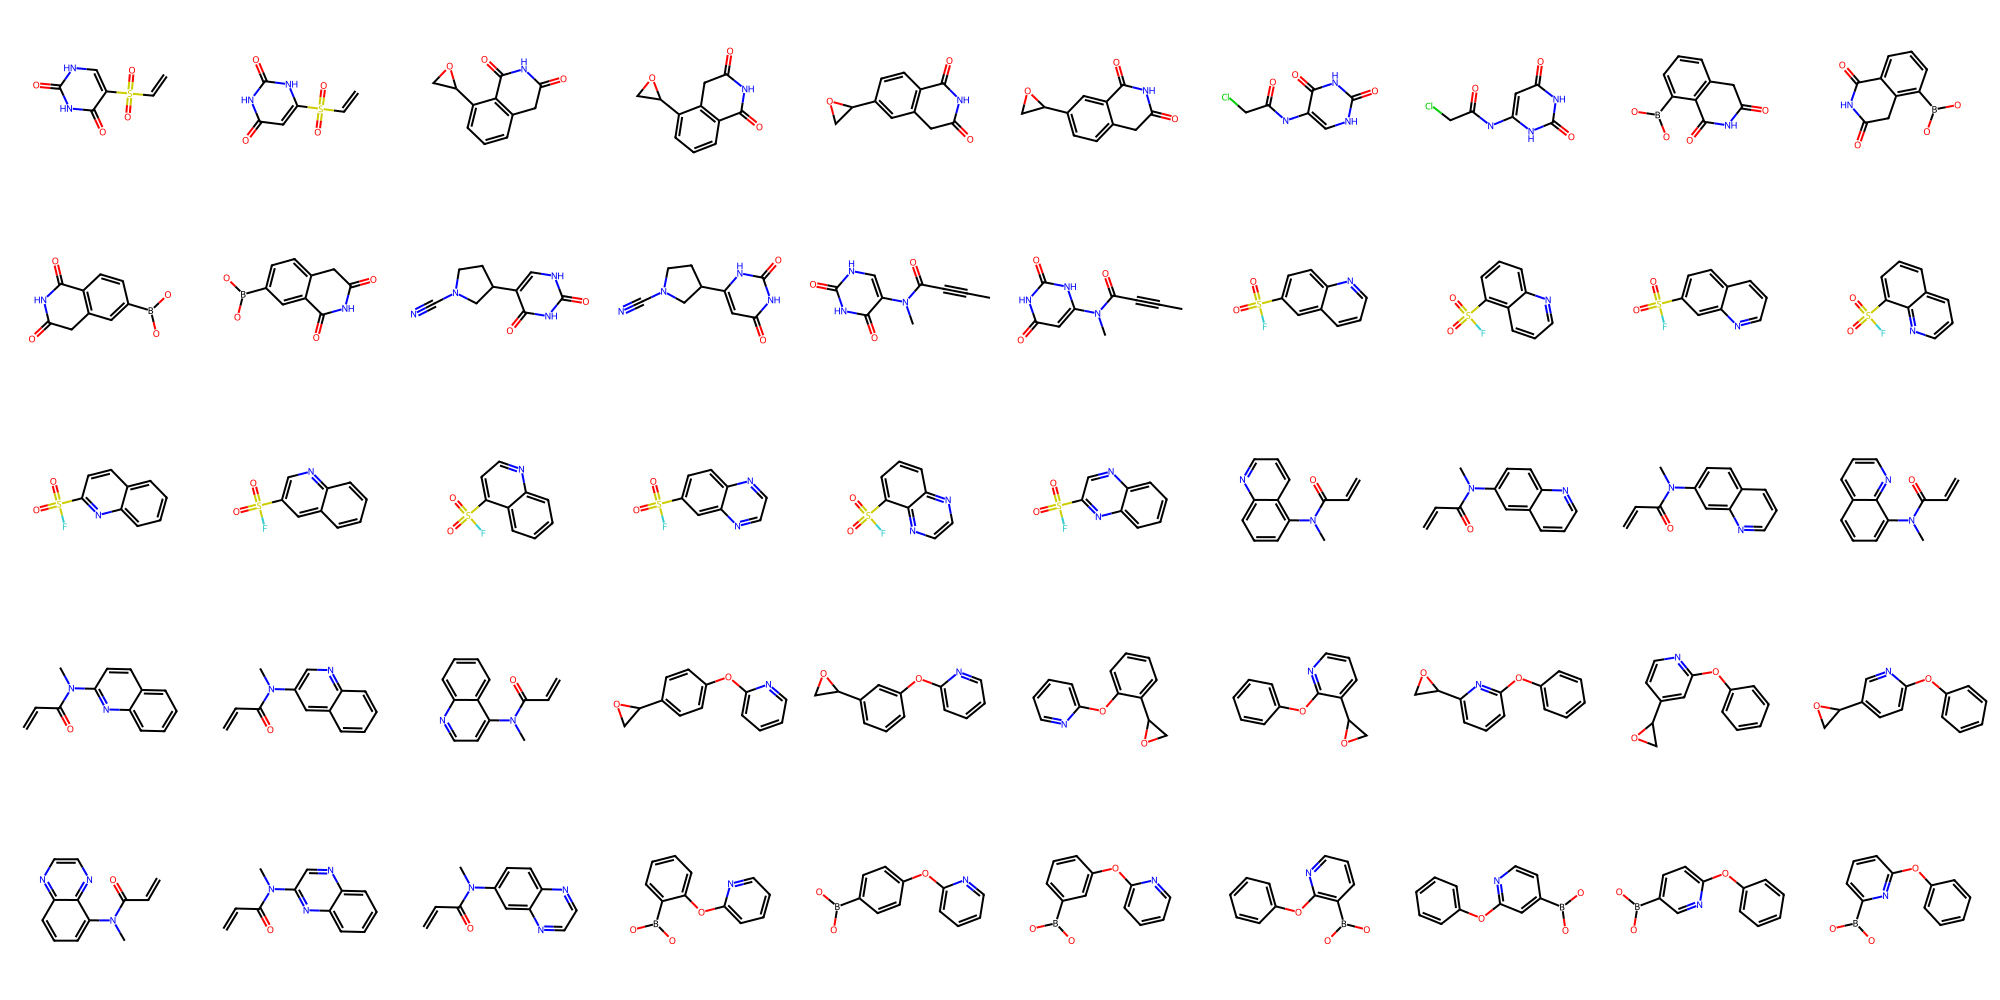

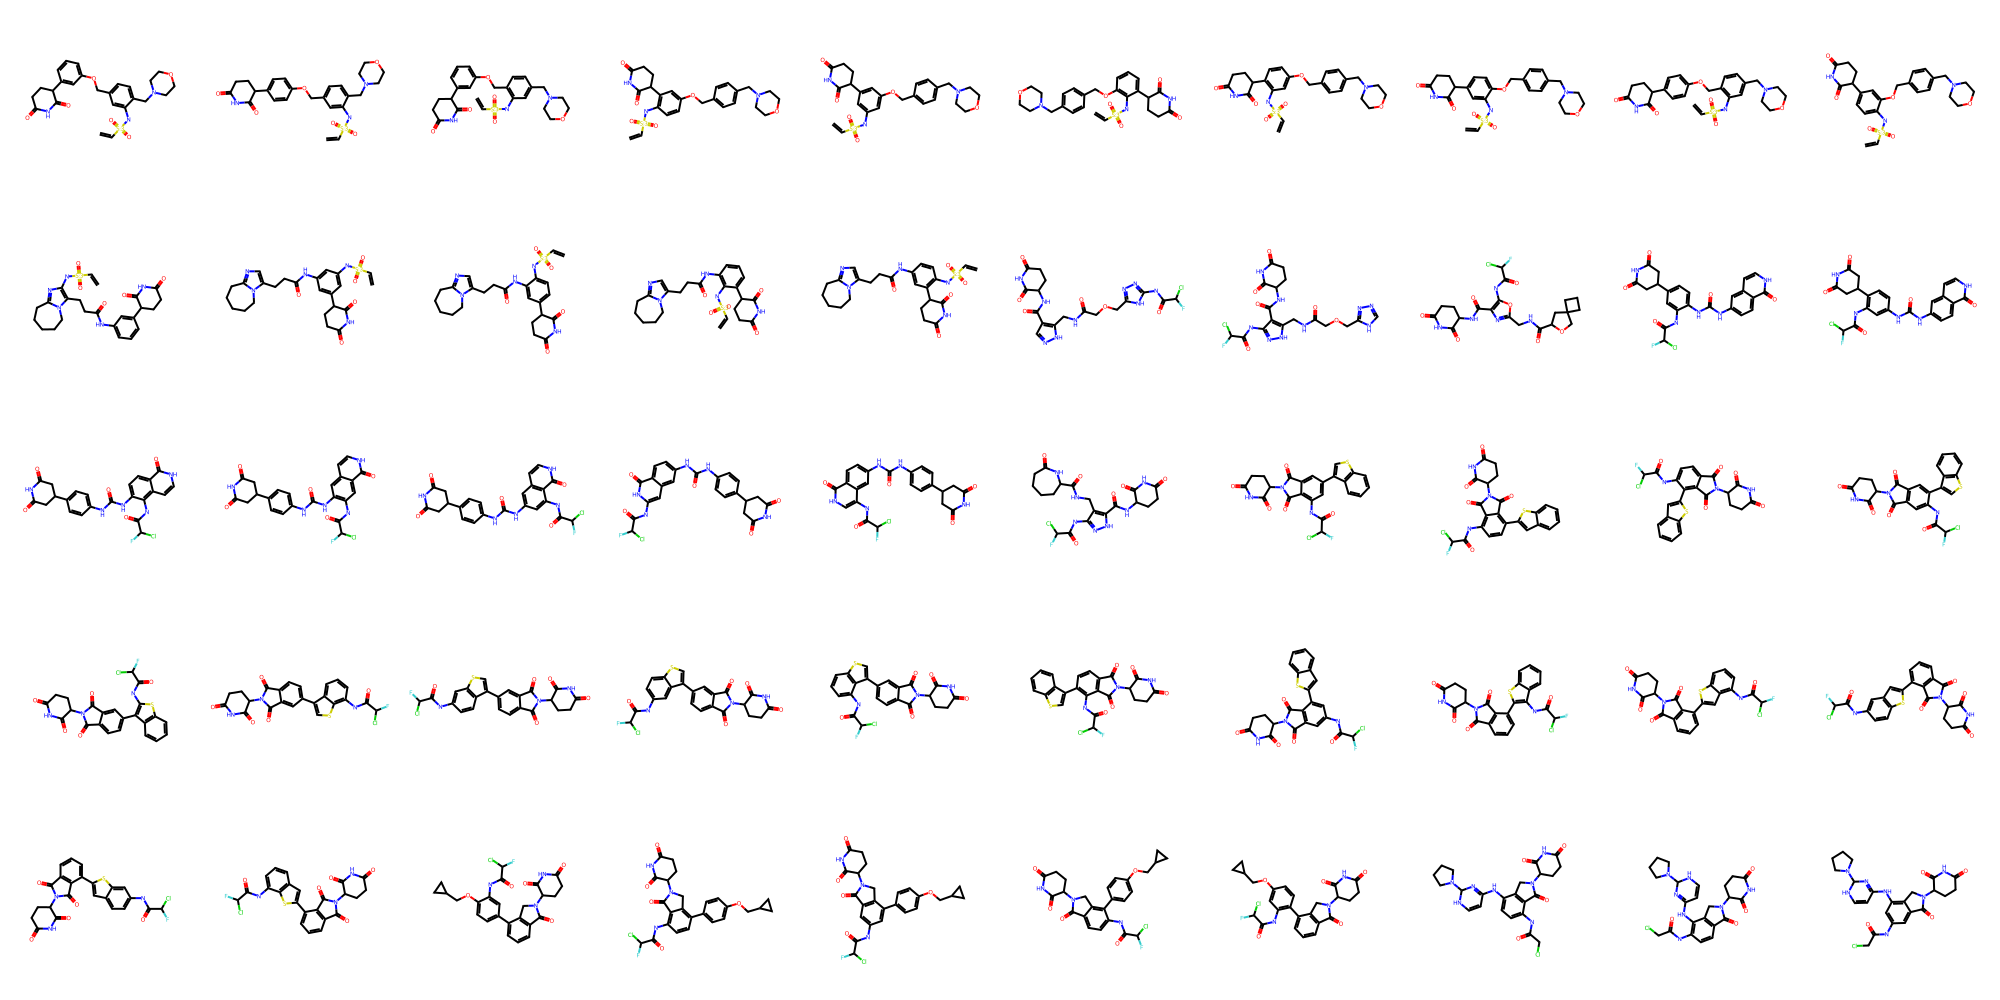

In [17]:
clean = sorted(clean, key=lambda x: Descriptors.MolWt(x), reverse=False)
clean_between_200_500 = [mol for mol in clean if 200 <= Descriptors.MolWt(mol) <= 500]
print(f'Number of clean compounds between 200 and 500 Da: {len(clean_between_200_500)}')
display(Draw.MolsToGridImage(clean_between_200_500[:50], molsPerRow=10))
display(Draw.MolsToGridImage(clean_between_200_500[-50:], molsPerRow=10))

Number of final clean compounds with imide substructure: 115008


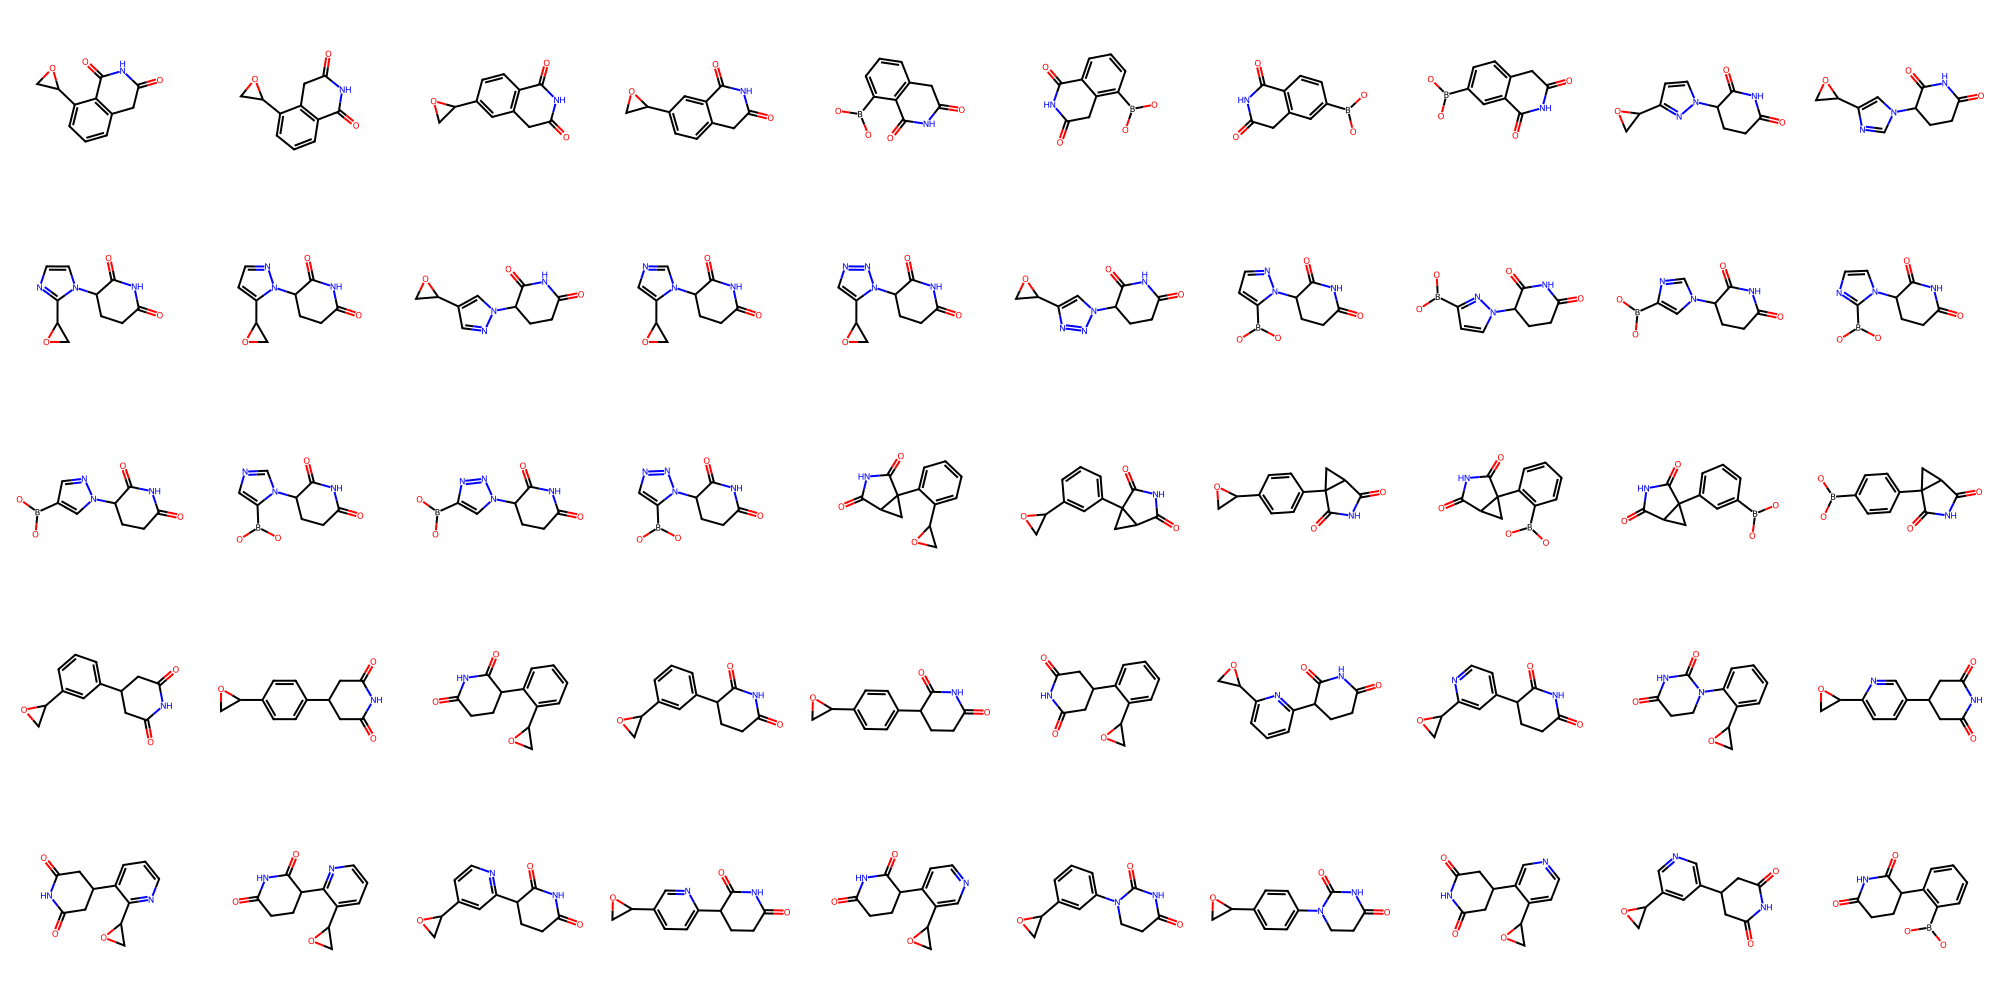

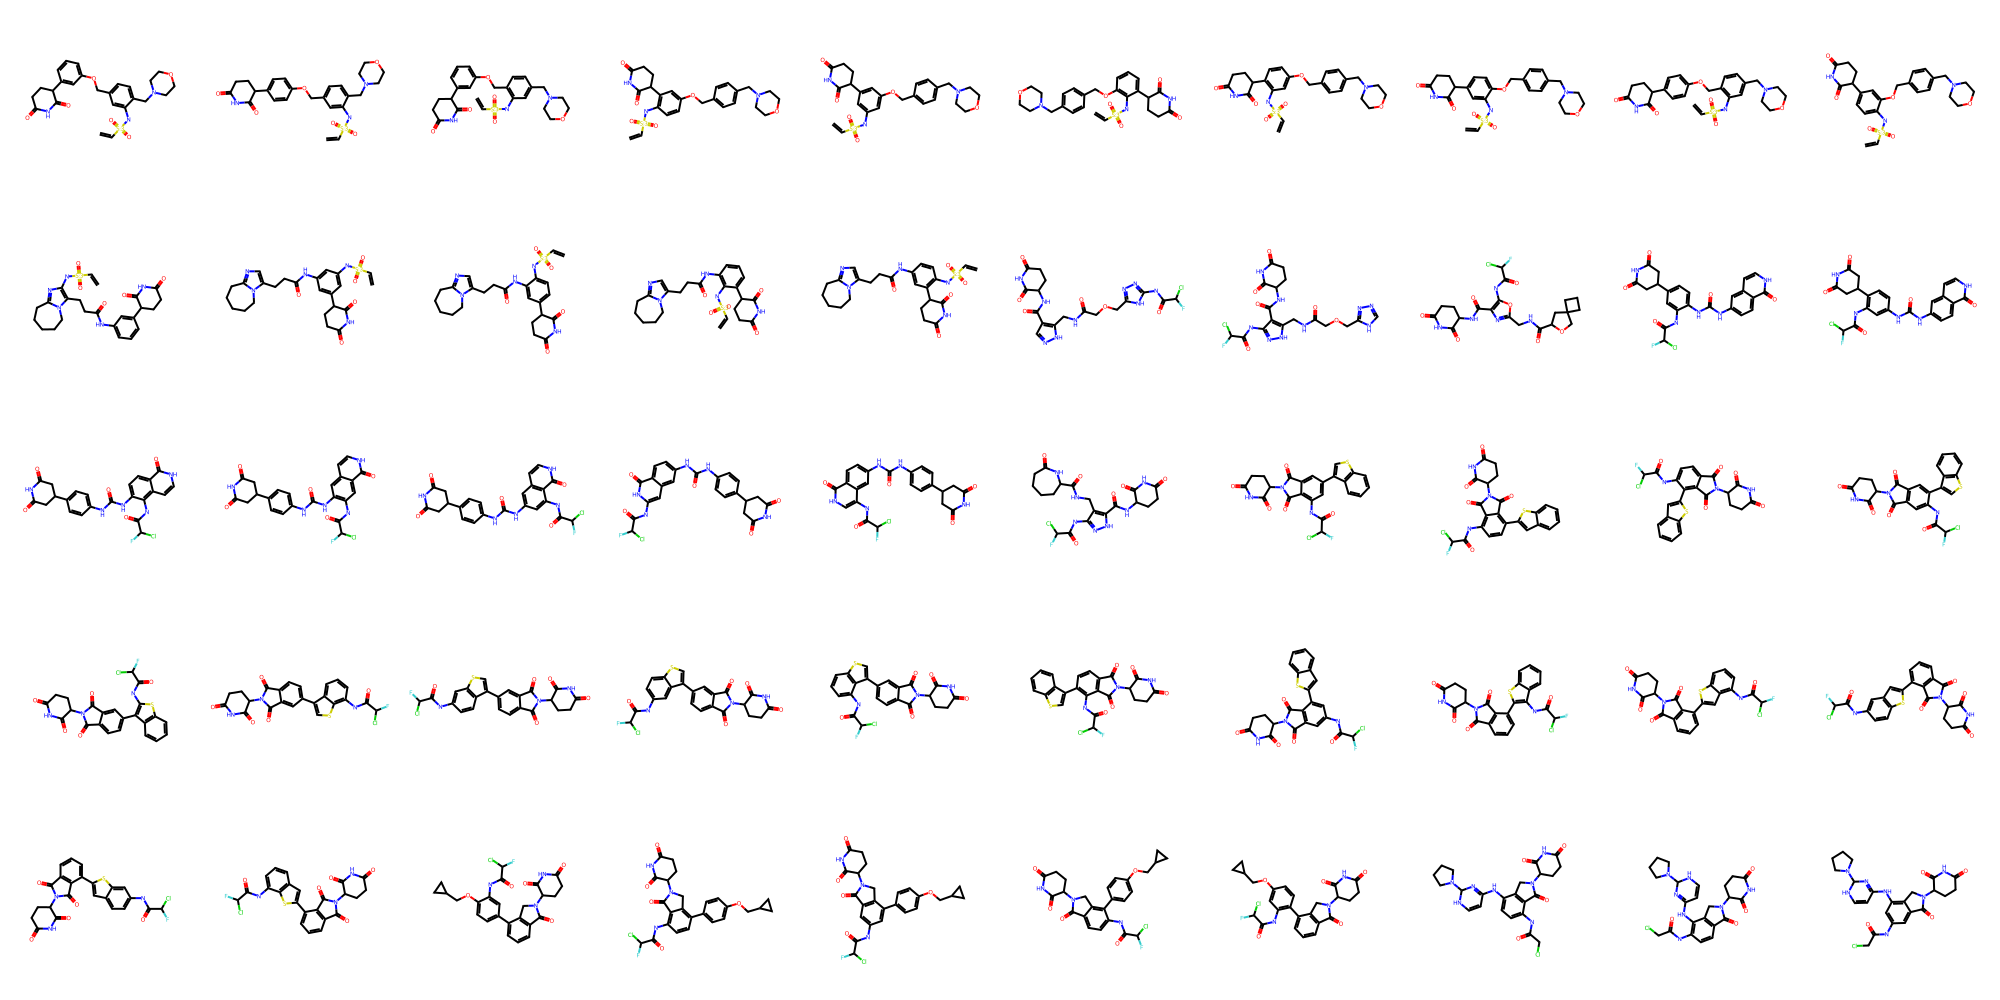

In [18]:
#check substructure imides
imide_smarts = 'C(=O)-[NH]-C(=O)'
imide_mol = Chem.MolFromSmarts(imide_smarts)
final_clean = []
for mol in clean_between_200_500:
    if mol.HasSubstructMatch(imide_mol):
        final_clean.append(mol)
print(f'Number of final clean compounds with imide substructure: {len(final_clean)}')
display(Draw.MolsToGridImage(final_clean[:50], molsPerRow=10))
display(Draw.MolsToGridImage(final_clean[-50:], molsPerRow=10))

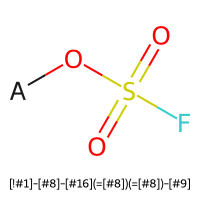

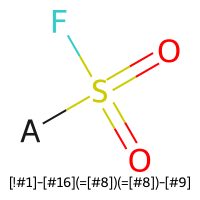

Number of final clean compounds with imide and sulf substructure: 9220


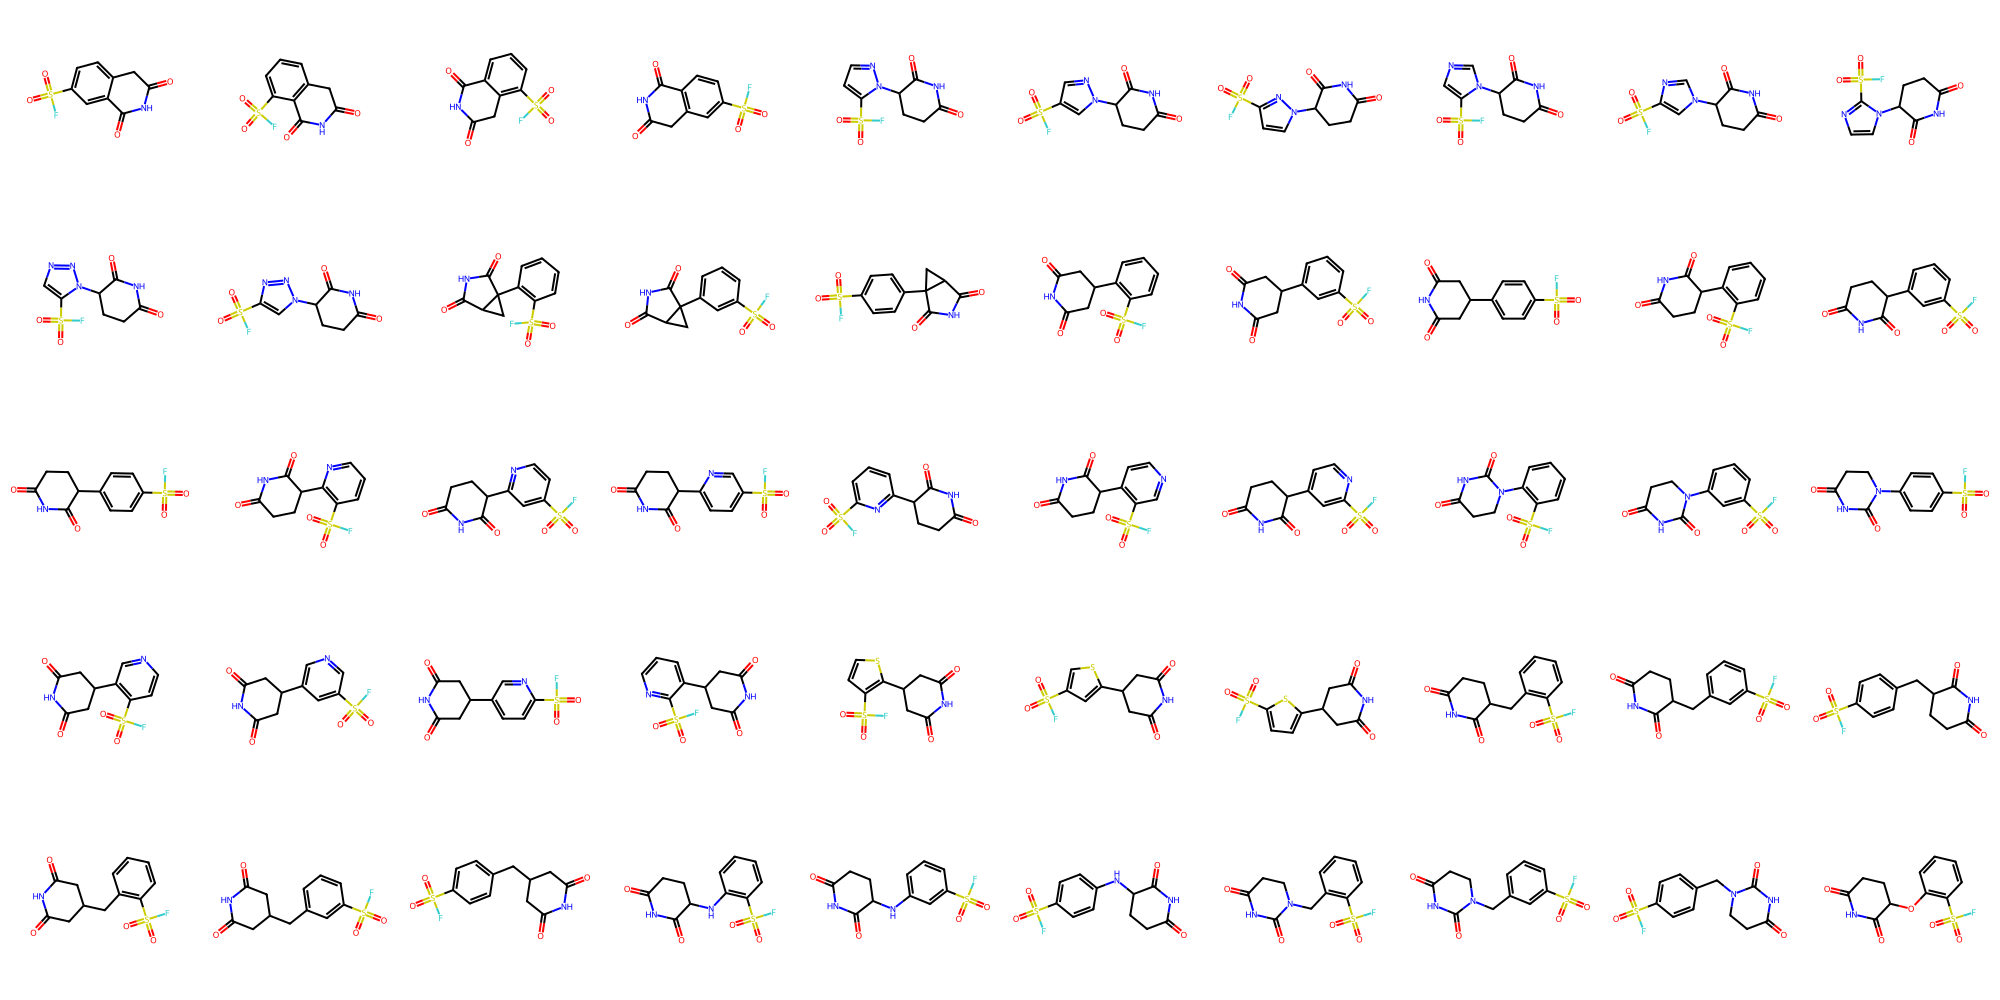

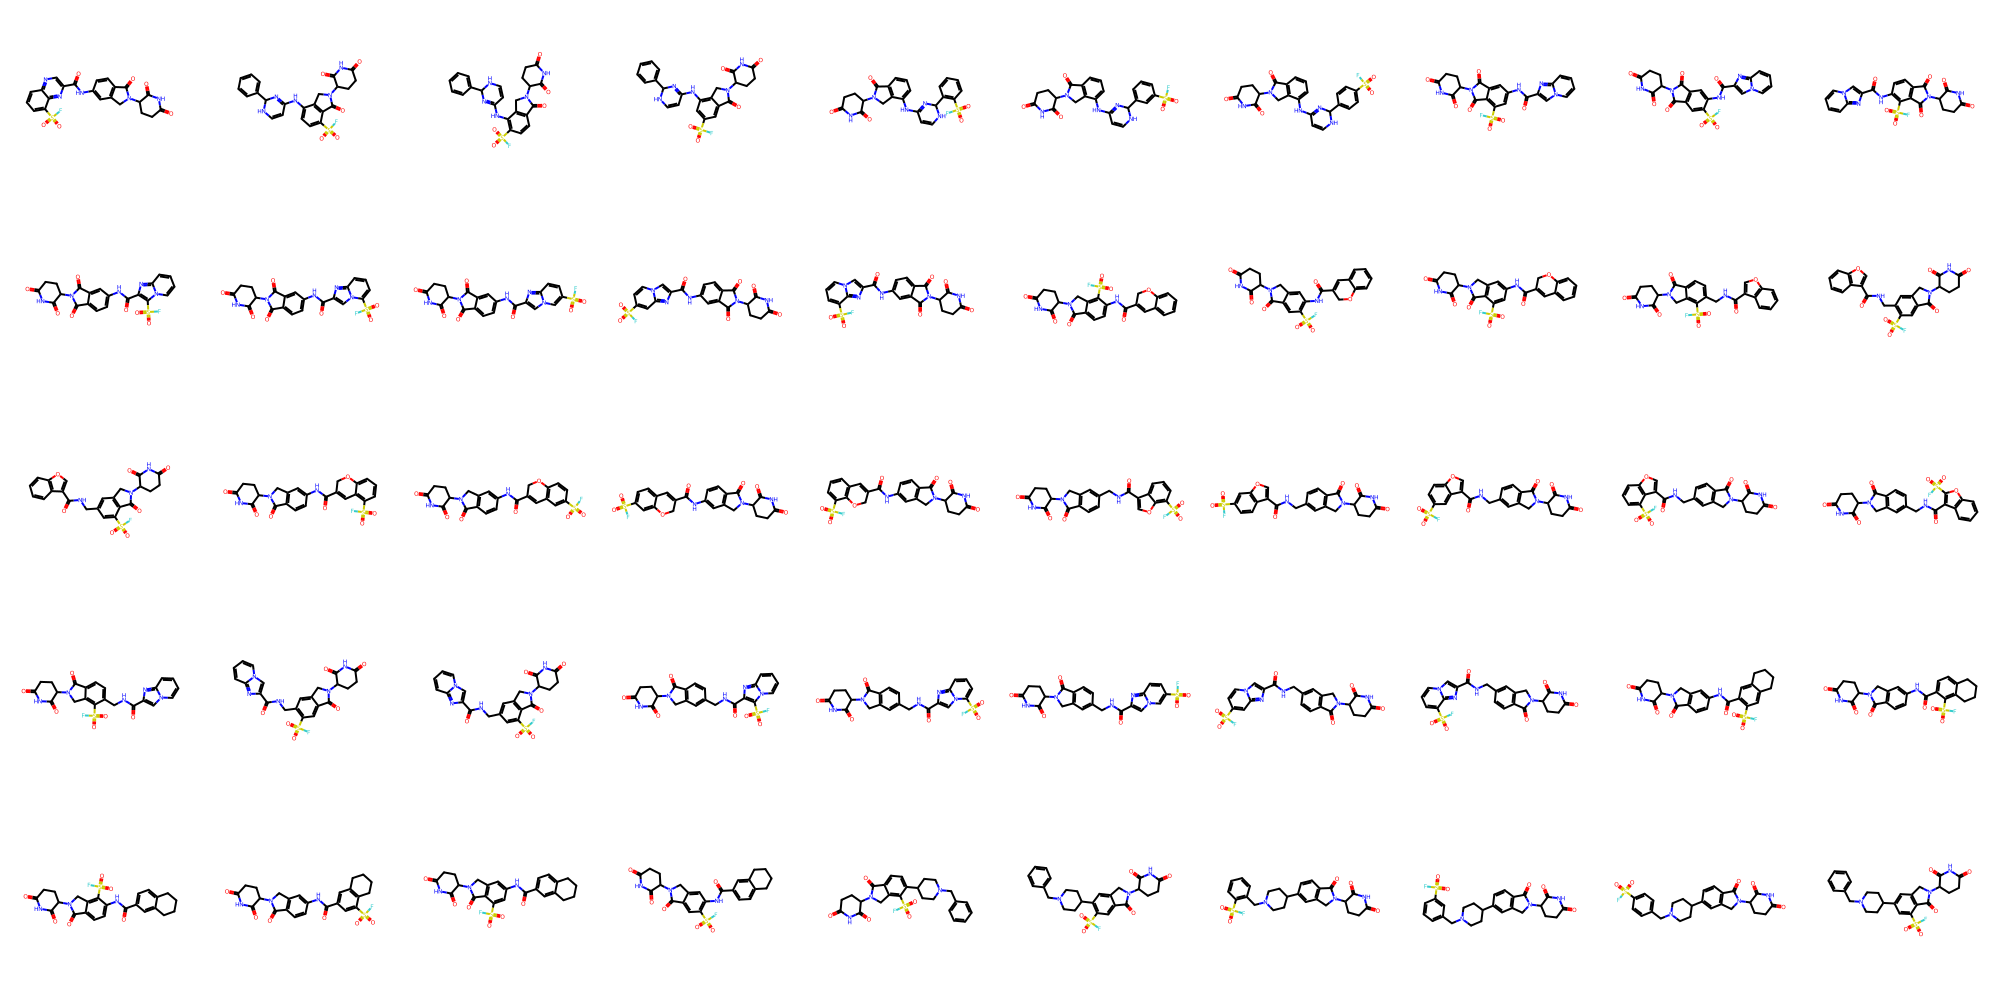

In [23]:
#check substructure imides and also sulf
sulf_smarts_list = [
'[!#1]-[#8]-[#16](=[#8])(=[#8])-[#9]',
'[!#1]-[#16](=[#8])(=[#8])-[#9]',
]
sulf_list = []
for i in sulf_smarts_list:
    warhead = Chem.MolFromSmarts(i)
    Chem.SanitizeMol(warhead)
    display(Draw.MolToImage(warhead, size=(200,200), legend=i))
    sulf_list.append(warhead)
final_clean_inc_sulf = []
for mol in final_clean:
    if any(mol.HasSubstructMatch(sulf) for sulf in sulf_list):
        final_clean_inc_sulf.append(mol)
print(f'Number of final clean compounds with imide and sulf substructure: {len(final_clean_inc_sulf)}')
display(Draw.MolsToGridImage(final_clean_inc_sulf[:50], molsPerRow=10))
display(Draw.MolsToGridImage(final_clean_inc_sulf[-50:], molsPerRow=10))

In [ ]:
#with Chem.SDWriter('covalent_docking_VS/binary/covalent_cereblon_binders_final_clean_inc_sulf.sdf') as writer:
with Chem.SDWriter('covalent_docking_VS/IKZF2/covalent_cereblon_binders_final_clean_inc_sulf.sdf') as writer:
    for mol in final_clean_inc_sulf:
        writer.write(mol)

In [7]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def get_shortest_path_between_smarts(smiles, smarts_source, source_atom_idx, smarts_sink, sink_atom_idx):
    # 1. Load Molecule and SMARTS
    mol = Chem.MolFromSmiles(smiles)
    q_source = Chem.MolFromSmarts(smarts_source)
    q_sink = Chem.MolFromSmarts(smarts_sink)
    
    if not all([mol, q_source, q_sink]):
        print("Error: Check your SMILES or SMARTS syntax.")
        return

    # 2. Identify start and end indices
    match_source = mol.GetSubstructMatch(q_source)
    match_sink = mol.GetSubstructMatch(q_sink)
    
    if not match_source or not match_sink:
        print(f"Match failed. Source: {bool(match_source)}, Sink: {bool(match_sink)}")
        return
    
    # We use the specified atom index of each match
    idx1, idx2 = match_source[source_atom_idx], match_sink[sink_atom_idx]

    # 3. Compute Shortest Path
    path_atoms = list(Chem.rdmolops.GetShortestPath(mol, idx1, idx2))
    if not path_atoms:
        print(f"No path exists between atom {idx1} and {idx2}.")
        return
        
    path_bonds = [mol.GetBondBetweenAtoms(path_atoms[i], path_atoms[i+1]).GetIdx() 
                  for i in range(len(path_atoms) - 1)]
    
    path_length = int(len(path_bonds))
    return path_length

long_mols = []
with Chem.SDMolSupplier('covalent_docking_VS/IKZF2/covalent_cereblon_binders_final_clean_inc_sulf.sdf') as supplier:
    for mol in supplier:
        smi = Chem.MolToSmiles(mol)
        path_length = get_shortest_path_between_smarts(smi, "[!#1]-[#6](-[#7]-[#6](-[!#1])=[#8])=[#8]", 2, "[!#1]-[#16](=[#8])(=[#8])-[#9]", 4)
        try:
            if path_length > 10:
                long_mols.append(mol)
        except:
            pass
#
with Chem.SDWriter('covalent_docking_VS/IKZF2/covalent_cereblon_binders_final_clean_inc_sulf_long.sdf') as writer:
    for mol in long_mols:
        writer.write(mol)

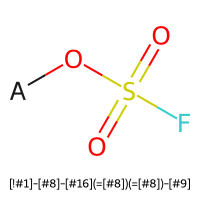

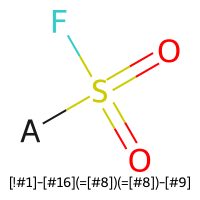

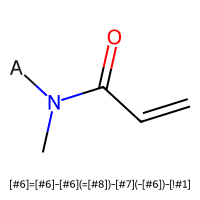

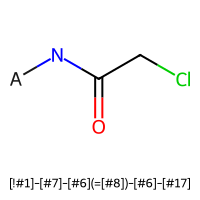

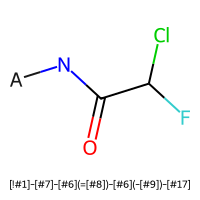

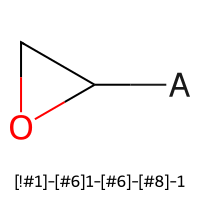

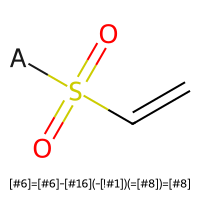

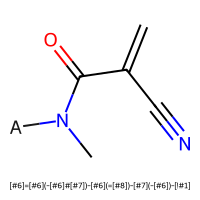

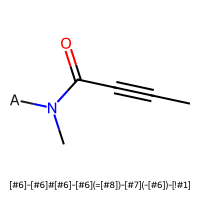

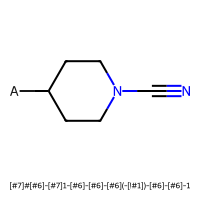

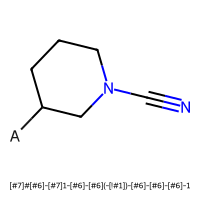

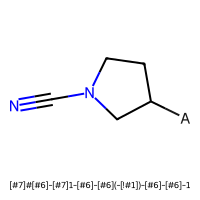

Number of final clean compounds with imide and cys substructure: 105432


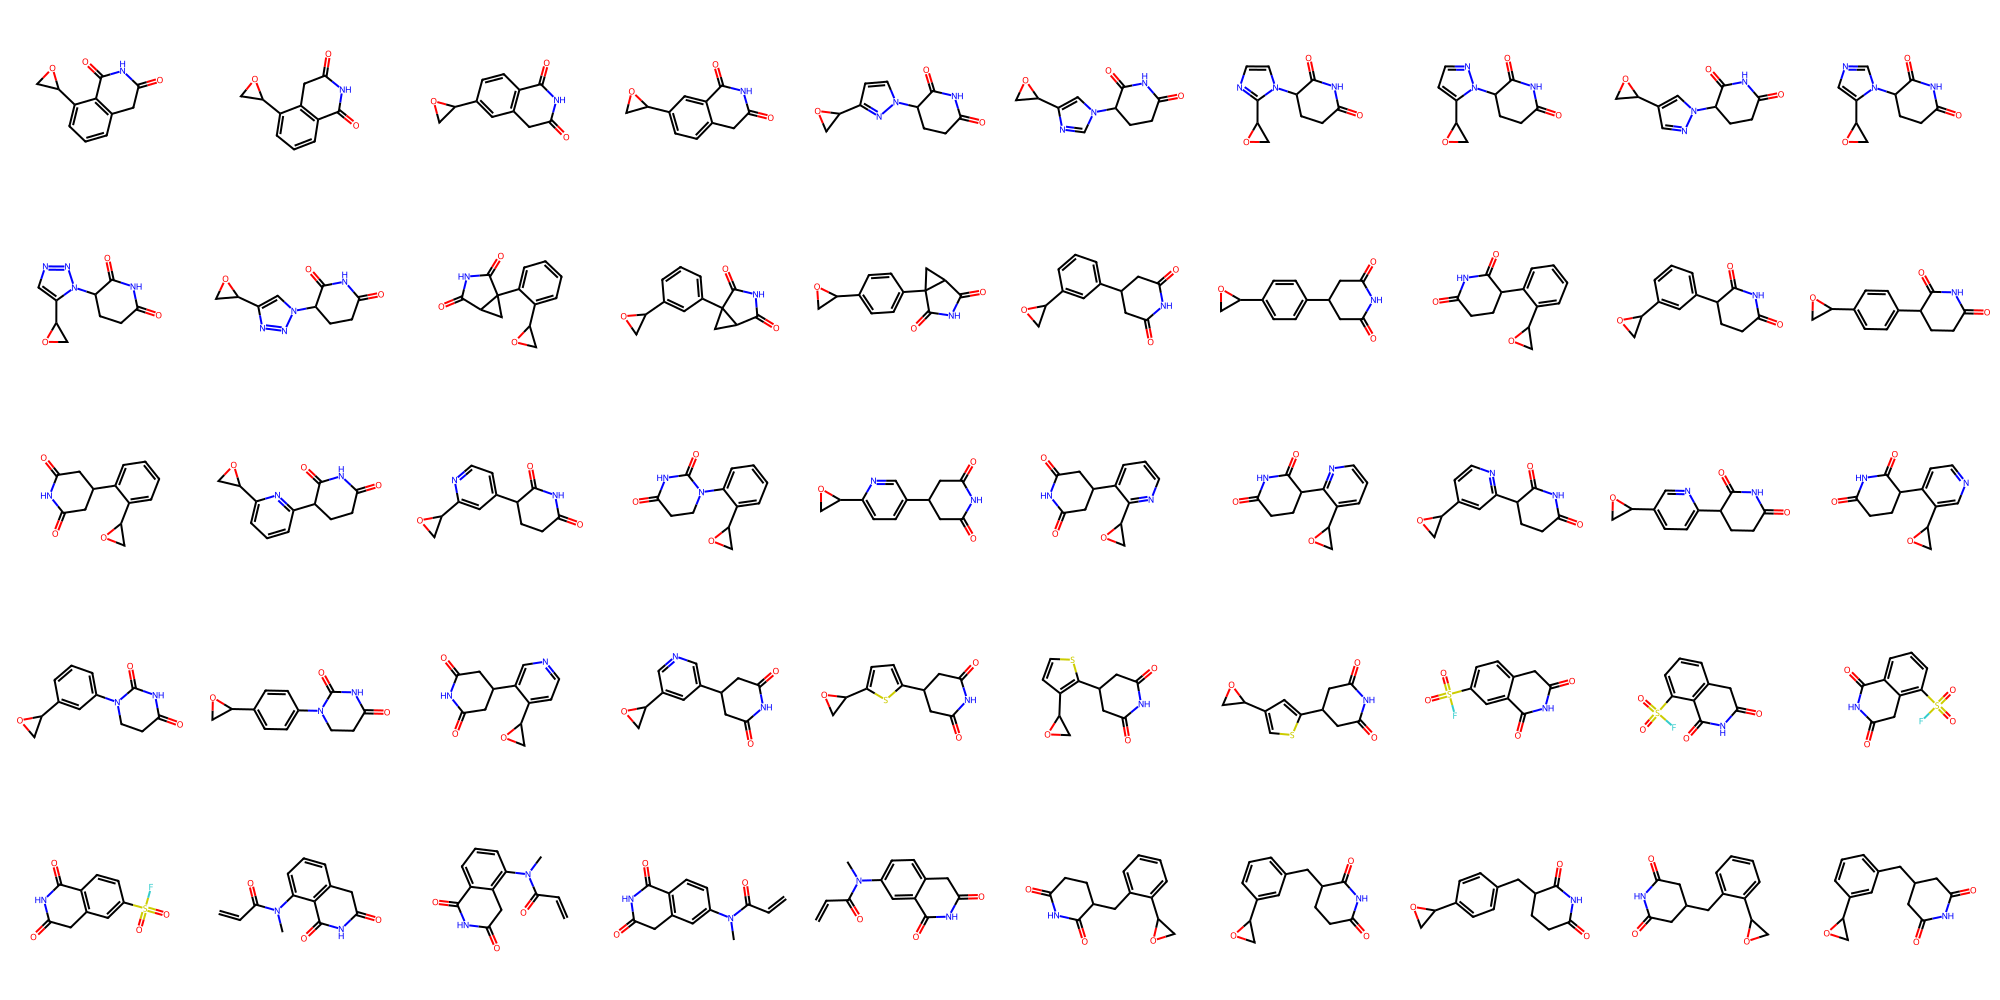

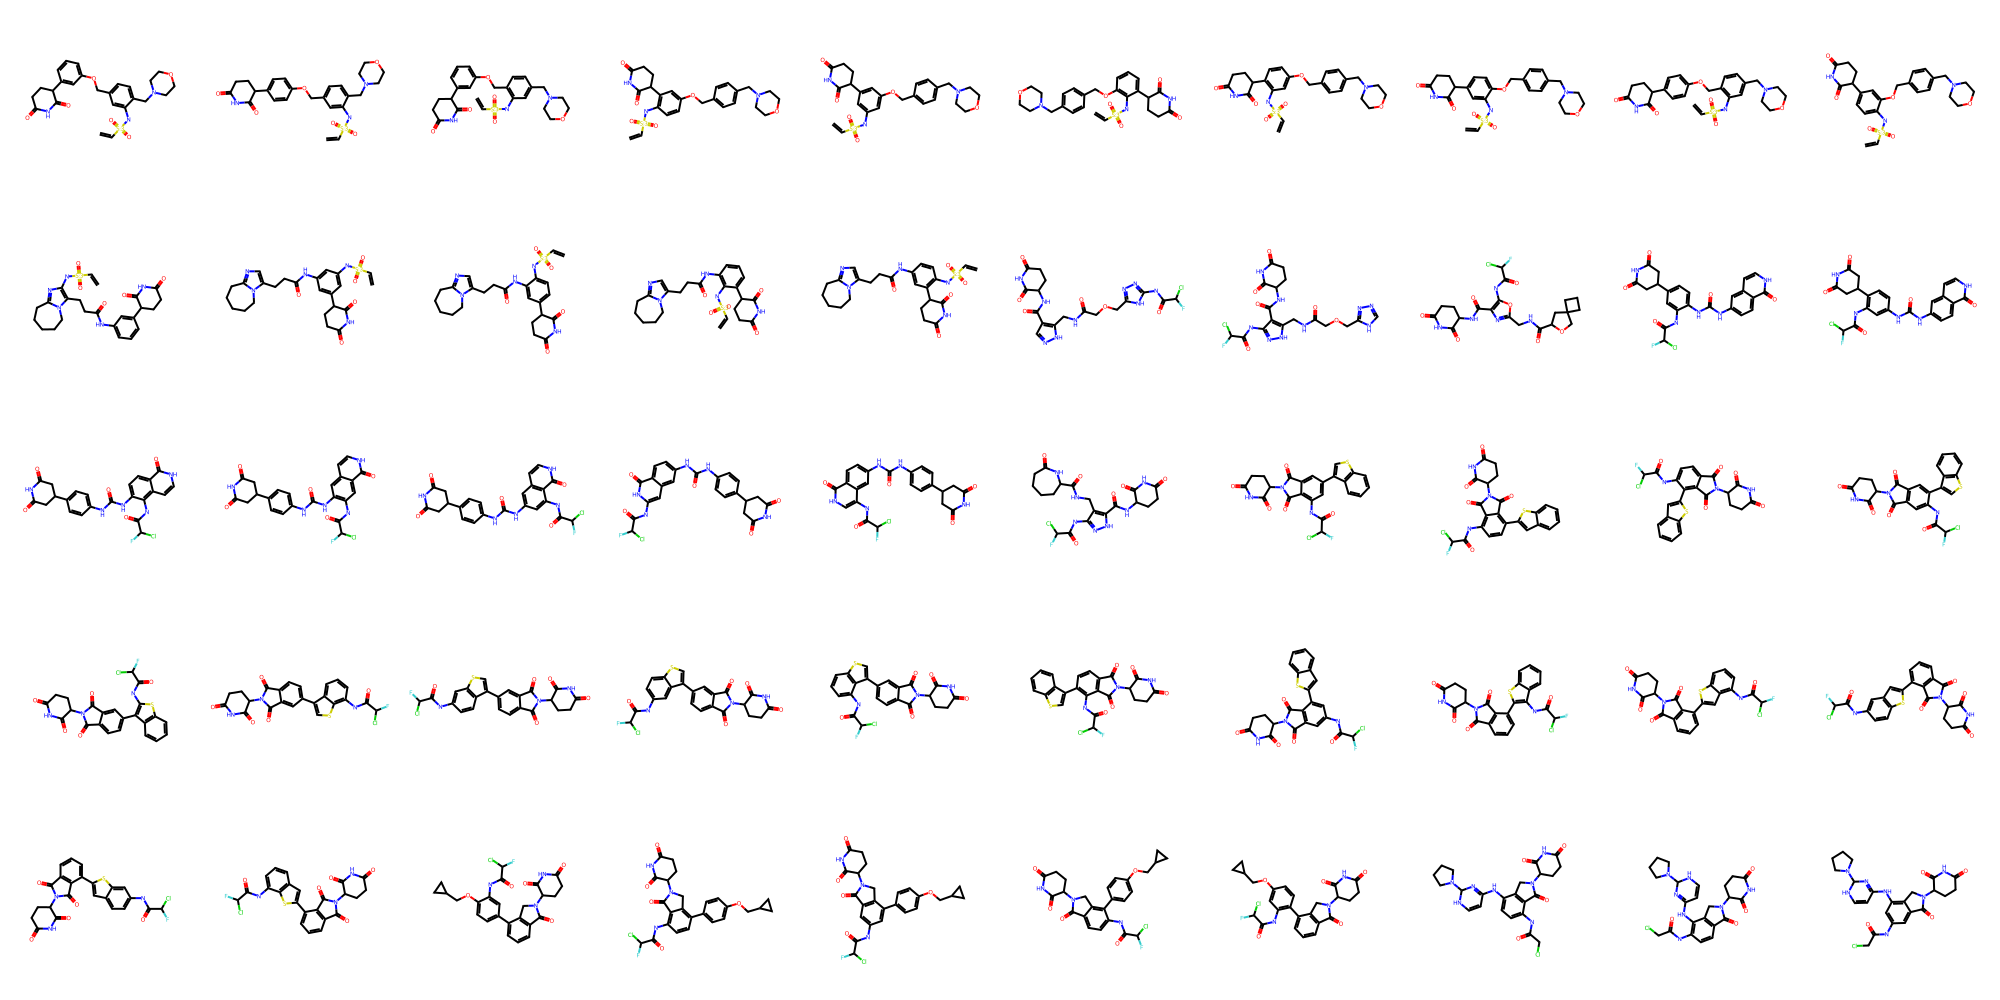

In [22]:
cys_covalent_smarts_list = [
'[!#1]-[#8]-[#16](=[#8])(=[#8])-[#9]',
'[!#1]-[#16](=[#8])(=[#8])-[#9]',
'[#6]=[#6]-[#6](=[#8])-[#7](-[#6])-[!#1]',
'[!#1]-[#7]-[#6](=[#8])-[#6]-[#17]',
'[!#1]-[#7]-[#6](=[#8])-[#6](-[#9])-[#17]',
'[!#1]-[#6]1-[#6]-[#8]-1',
'[#6]=[#6]-[#16](-[!#1])(=[#8])=[#8]',
'[#6]=[#6](-[#6]#[#7])-[#6](=[#8])-[#7](-[#6])-[!#1]',
'[#6]-[#6]#[#6]-[#6](=[#8])-[#7](-[#6])-[!#1]',
'[#7]#[#6]-[#7]1-[#6]-[#6]-[#6](-[!#1])-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6](-[!#1])-[#6]-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6](-[!#1])-[#6]-[#6]-1'
]
cys_target_list = []
for i in cys_covalent_smarts_list:
    warhead = Chem.MolFromSmarts(i)
    Chem.SanitizeMol(warhead)
    display(Draw.MolToImage(warhead, size=(200,200), legend=i))
    cys_target_list.append(warhead)
final_clean_target_cys = []
for mol in final_clean:
    if any(mol.HasSubstructMatch(cys_warhead) for cys_warhead in cys_target_list):
        final_clean_target_cys.append(mol)
print(f'Number of final clean compounds with imide and cys substructure: {len(final_clean_target_cys)}')
display(Draw.MolsToGridImage(final_clean_target_cys[:50], molsPerRow=10))
display(Draw.MolsToGridImage(final_clean_target_cys[-50:], molsPerRow=10))

In [23]:
with Chem.SDWriter('covalent_docking_VS/WIZ/covalent_cereblon_binders_final_clean_target_cys.sdf') as writer:
    for mol in final_clean_target_cys:
        writer.write(mol)